<a href="https://colab.research.google.com/github/cathrineq/python-ai-Tarasova-Kate/blob/main/notebooks/viz1_currency_clusters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование и загрузка

**Что делаем:**
- Клонируем репозиторий `python-ai-Tarasova-Kate` в Colab
- Загружаем 2 CSV-файла из Wikidata:
  - `currency_rates.csv` — курсы валют (P2284) с метками времени (P585, P580)
  - `countries_currencies.csv` — страны + официальные валюты (P38, P1082, P2046)
- Очищаем данные:
  - 🔗 URL Wikidata → переименовываем (`URL`, `country_URL`, `currency_URL`) — **не удаляем!**
  - 🏷️ `*Label` → короткие имена (`currency`, `unit`, `country`)
  - 📊 Числовые поля → `float`, пропуски (`NaN`) **не заменяем на 0**
  - 📈 Измеряем заполненность `OPTIONAL`-полей перед очисткой

**Результат:**

📊 `df_rates` — курсы валют по времени
| Столбец | Описание |
|---------|----------|
| `URL` | Ссылка на валюту в Wikidata 🔑 |
| `currency` | Название валюты |
| `price` | Курс в евро (float, возможны NaN) |
| `year` / `startYear` | Год данных (float, возможны NaN) |
| `unit` / `unitSymbol` | Единица измерения и символ |

🌍 `df_countries` — страны и их валюты
| Столбец | Описание |
|---------|----------|
| `country_URL` | Ссылка на страну в Wikidata |
| `country` | Название страны |
| `currency_URL` | Ссылка на валюту 🔑 (ключ для `merge`) |
| `currency` | Название валюты |
| `population` / `area` | Население и площадь (float, возможны NaN) |

> 💡 **Важно:** Столбцы `URL` / `currency_URL` сохранены для:  
> 1) отладки аномалий (клик → запись в Wikidata)  
> 2) надёжного объединения таблиц через `pd.merge(on="currency_URL")`

In [4]:
# ============================================================
#  ЯЧЕЙКА 1: Подготовка данных (для viz1 и viz2)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Клонируем репозиторий (если ещё не клонирован)
repo = "python-ai-Tarasova-Kate"
repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/cathrineq/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

# 2. Загружаем сырые CSV-файлы
df_rates_raw = pd.read_csv("data/currency_rates.csv")
df_countries_raw = pd.read_csv("data/countries_currencies.csv")

# 3. Очистка и переименование столбцов для df_rates (как в задании 2)
df_rates = df_rates_raw.rename(columns={
    "currency": "URL",
    "currencyLabel": "currency",
    "unitLabel": "unit"
}, errors="ignore")

# Приводим числовые столбцы к float (NaN, если не число)
df_rates["price"] = pd.to_numeric(df_rates["price"], errors="coerce")
if "year" in df_rates.columns:
    df_rates["year"] = pd.to_numeric(df_rates["year"], errors="coerce")
if "startYear" in df_rates.columns:
    df_rates["startYear"] = pd.to_numeric(df_rates["startYear"], errors="coerce")

# 4. Очистка для df_countries (переименовываем URL и Label)
df_countries = df_countries_raw.rename(columns={
    "country": "country_URL",
    "currency": "currency_URL",
    "countryLabel": "country",
    "currencyLabel": "currency"
}, errors="ignore")

# Приводим числовые столбцы
df_countries["population"] = pd.to_numeric(df_countries["population"], errors="coerce")
df_countries["area"] = pd.to_numeric(df_countries["area"], errors="coerce")

# 5. Документируем выбросы по цене (очень большие значения)
outliers = df_rates[df_rates["price"] >= 1e8]  # 100 миллионов и больше
if len(outliers) > 0:
    print("⚠️ ВНИМАНИЕ: Обнаружены выбросы по цене (≥ 100 000 000 евро):")
    print(outliers[["URL", "currency", "price", "year", "unit"]].to_string())
    print("\nЭти выбросы могут искажать цветовую шкалу на графиках.")
    print("В viz1 мы их временно исключим (оставим только цены < 1e8).\n")
else:
    print("✅ Выбросов по цене не обнаружено.\n")

# 6. Создаём df_unique_countries (уникальные страны, агрегированные)
#    Это нужно для второй визуализации (карта с дугами), но можно создать сразу.
df_unique_countries = (
    df_countries
    .groupby("country_URL")
    .agg(
        country=("country", "first"),               # название страны
        n_currencies=("currency_URL", "nunique"),  # сколько разных валют было у страны
        population=("population", "max"),          # население (берём максимум, если несколько записей)
        area=("area", "max")                       # площадь
    )
    .reset_index()
)
print(f"✅ df_unique_countries: {len(df_unique_countries)} уникальных стран (из {len(df_countries)} строк)")

# 7. Краткая информация о данных (для проверки)
print("\n📊 df_rates:", df_rates.shape)
print("Столбцы:", df_rates.columns.tolist())
print("\n📊 df_countries:", df_countries.shape)
print("Столбцы:", df_countries.columns.tolist())
print("\n✅ Подготовка данных завершена.")

⚠️ ВНИМАНИЕ: Обнаружены выбросы по цене (≥ 100 000 000 евро):
                                           URL            currency         price    year                   unit
523   http://www.wikidata.org/entity/Q56349362  Суверенный боливар  1.000000e+08  2018.0  венесуэльский боливар
526   http://www.wikidata.org/entity/Q56349362  Суверенный боливар  1.000000e+08  2018.0  венесуэльский боливар
529   http://www.wikidata.org/entity/Q56349362  Суверенный боливар  1.000000e+08  2018.0  венесуэльский боливар
1417    http://www.wikidata.org/entity/Q260447       рентная марка  1.000000e+09  1923.0             рейхсмарка

Эти выбросы могут искажать цветовую шкалу на графиках.
В viz1 мы их временно исключим (оставим только цены < 1e8).

✅ df_unique_countries: 209 уникальных стран (из 803 строк)

📊 df_rates: (2346, 8)
Столбцы: ['URL', 'currency', 'shortName', 'price', 'year', 'startYear', 'unit', 'unitSymbol']

📊 df_countries: (803, 7)
Столбцы: ['country_URL', 'country', 'currency_URL', 'curren

#🌟Кластеризованная тепловая карта (clustermap)


Записей после фильтрации: 238
Размер сводной таблицы: (8, 4)
Уникальные континенты в данных: {'Другое', 'Европа'}
Число валют в анализе: 8


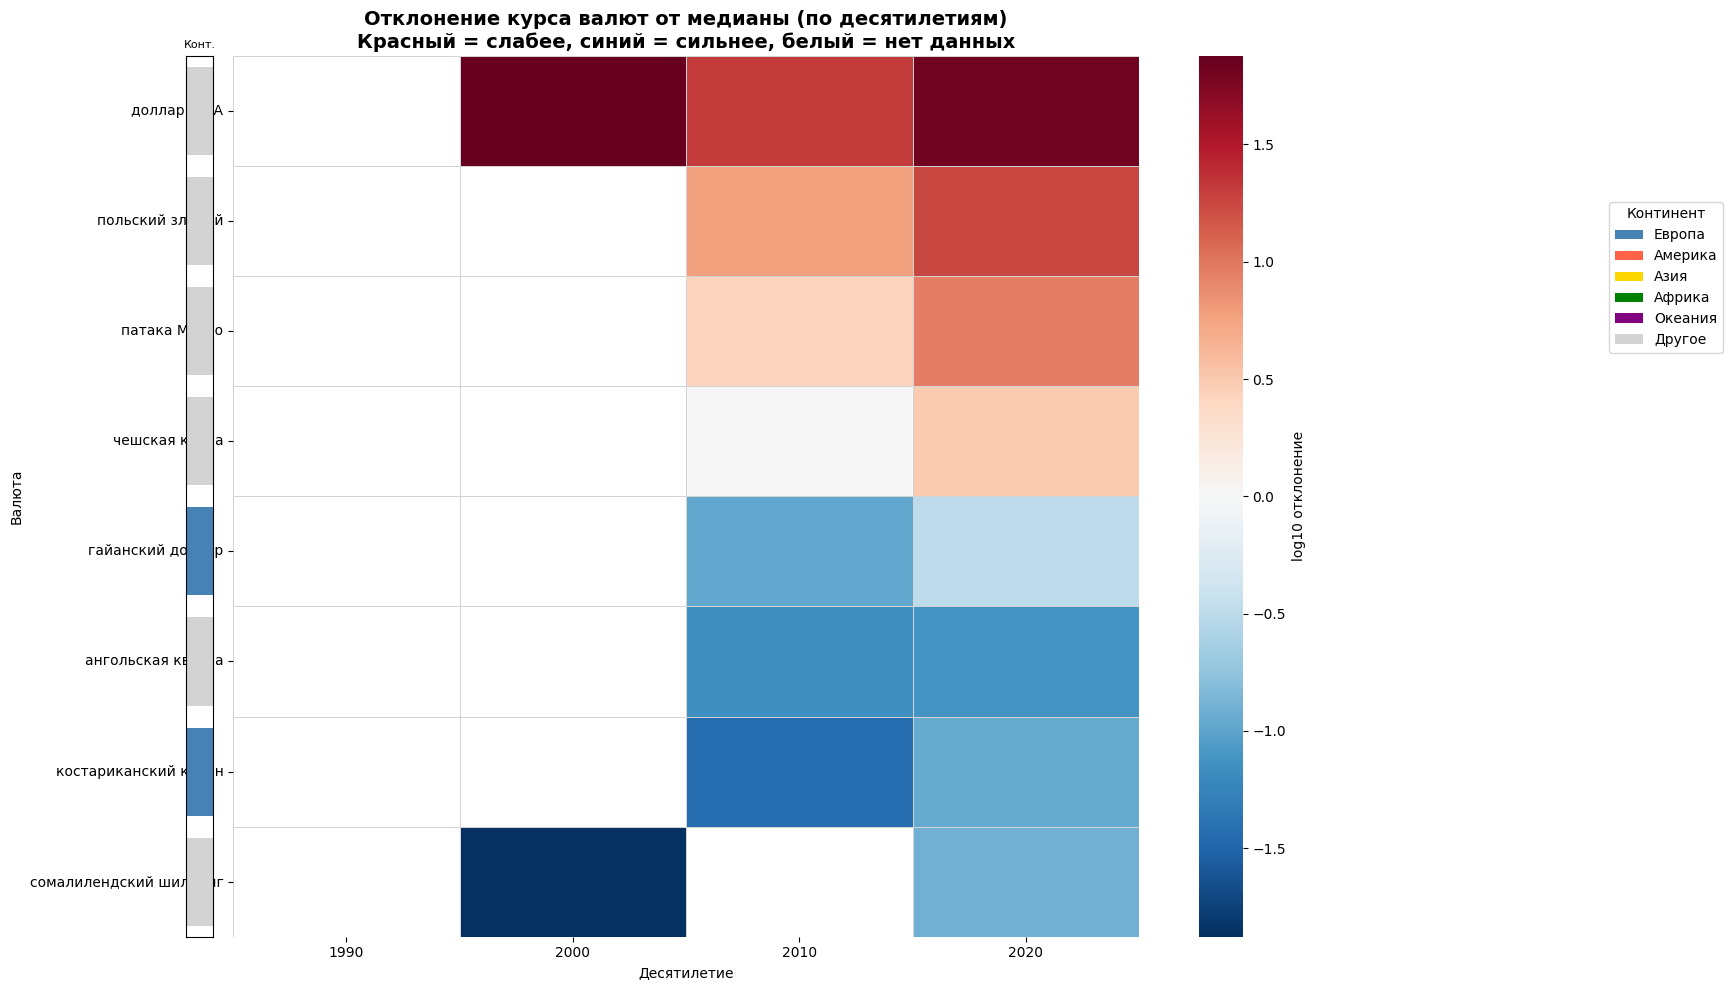

✅ Тепловая карта построена без заполнения пропусков (NaN отображаются белым).
Проанализировано валют: 8


In [5]:
# ============================================================
#  ЯЧЕЙКА 2: Тепловая карта (без кластеризации, без fillna(0))
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ------------------- НАСТРОЙКИ -------------------
USE_DECADES = True
USE_DEVIATION = True
REMOVE_OUTLIERS = True
MIN_POINTS_PER_CURRENCY = 2   # валюта должна иметь данные хотя бы в 2 десятилетиях

# 1. Подготовка данных с best_year
df_rates_clust = df_rates.copy()
df_rates_clust["best_year"] = df_rates_clust["year"].fillna(df_rates_clust["startYear"])

df_eur = df_rates_clust[
    (df_rates_clust["unit"] == "евро") &
    (df_rates_clust["best_year"].notna()) &
    (df_rates_clust["price"] > 0)
].copy()

if REMOVE_OUTLIERS:
    df_eur = df_eur[df_eur["price"] < 1e8]

print(f"Записей после фильтрации: {len(df_eur)}")

df_eur["log_price"] = np.log10(df_eur["price"])
if USE_DECADES:
    df_eur["time_bin"] = (df_eur["best_year"] // 10 * 10).astype(int)
    time_label = "Десятилетие"
else:
    df_eur["time_bin"] = df_eur["best_year"]
    time_label = "Год"

# Сводная таблица
pivot = df_eur.pivot_table(index="currency", columns="time_bin", values="log_price", aggfunc="mean")
pivot = pivot.dropna(thresh=MIN_POINTS_PER_CURRENCY, axis=0)
pivot = pivot.reindex(sorted(pivot.columns), axis=1)

print(f"Размер сводной таблицы: {pivot.shape}")

if pivot.shape[0] < 2:
    raise ValueError("Меньше 2 валют. Уменьшите MIN_POINTS_PER_CURRENCY до 1.")

# Нормализация (отклонение от медианы)
if USE_DEVIATION:
    pivot_norm = pivot.sub(pivot.median(axis=0), axis=1)
    cmap = "RdBu_r"
    center = 0
    title = "Отклонение курса валют от медианы (по десятилетиям)\nКрасный = слабее, синий = сильнее, белый = нет данных"
    cbar_label = "log10 отклонение"
else:
    pivot_norm = pivot
    cmap = "viridis"
    center = None
    title = "Абсолютный логарифм курса валют к евро"
    cbar_label = "log10(price)"

# НЕ заполняем NaN – оставляем как есть

# Сортируем строки по среднему отклонению (от сильных к слабым)
row_order = pivot_norm.mean(axis=1, skipna=True).sort_values(ascending=False).index
pivot_norm = pivot_norm.loc[row_order]

# 2. Row_colors: континенты для валют
currency_to_country = df_countries.groupby("currency")["country"].first().to_dict()
continent_map = {
    "Россия": "Европа", "Германия": "Европа", "Франция": "Европа", "Польша": "Европа",
    "Швеция": "Европа", "Норвегия": "Европа", "Чехия": "Европа", "Венгрия": "Европа",
    "Украина": "Европа", "Беларусь": "Европа", "США": "Америка", "Канада": "Америка",
    "Бразилия": "Америка", "Аргентина": "Америка", "Мексика": "Америка",
    "Китай": "Азия", "Япония": "Азия", "Индия": "Азия", "Турция": "Азия",
    "Казахстан": "Азия", "Австралия": "Океания", "Египет": "Африка", "ЮАР": "Африка"
}
def get_continent(currency):
    country = currency_to_country.get(currency)
    if country and country in continent_map:
        return continent_map[country]
    return "Другое"

continent_colors = {
    "Европа": "steelblue",
    "Америка": "tomato",
    "Азия": "gold",
    "Африка": "green",
    "Океания": "purple",
    "Другое": "lightgray"
}
row_colors = [continent_colors.get(get_continent(curr), "lightgray") for curr in pivot_norm.index]

print("Уникальные континенты в данных:", set(get_continent(curr) for curr in pivot_norm.index))
print(f"Число валют в анализе: {len(pivot_norm)}")

# 3. Построение тепловой карты
fig, ax = plt.subplots(figsize=(14, 10))
heatmap = sns.heatmap(
    pivot_norm,
    cmap=cmap,
    center=center,
    cbar_kws={"label": cbar_label},
    linewidths=0.5,
    linecolor='lightgray',
    xticklabels=True,
    yticklabels=True,
    ax=ax
)
ax.set_xlabel(time_label)
ax.set_ylabel("Валюта")
ax.set_title(title, fontsize=14, fontweight='bold')

# Добавляем полоску континентов слева
divider = make_axes_locatable(ax)
cax = divider.append_axes("left", size="3%", pad=0.2)
for i, color in enumerate(row_colors):
    cax.barh(i, 1, color=color, edgecolor='none')
cax.set_xlim(0, 1)
cax.set_ylim(-0.5, len(row_colors)-0.5)
cax.set_xticks([])
cax.set_yticks([])
cax.set_title("Конт.", fontsize=8)

# Легенда для континентов
legend_elements = [Patch(facecolor=color, label=cont) for cont, color in continent_colors.items()]
fig.legend(handles=legend_elements, title="Континент", bbox_to_anchor=(1.15, 0.8), loc='upper left')

plt.tight_layout()
plt.show()

print("✅ Тепловая карта построена без заполнения пропусков (NaN отображаются белым).")
print(f"Проанализировано валют: {len(pivot_norm)}")